In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as mtick

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
def calculate_changes(df1_openalex, df2_walden, on):
    changes = pd.merge(df1_openalex, df2_walden, on=on, how='outer', suffixes=('_old', '_new'))

    changes['n_old'] = changes['n_old'].fillna(0)
    changes['n_new'] = changes['n_new'].fillna(0)
    changes = changes[[on, 'n_old', 'n_new']]

    changes['change'] = changes['n_new'] - changes['n_old']
    changes['pct_change'] = (changes['n_new'] - changes['n_old']) / changes['n_old'] * 100

    return changes

In [4]:
client = bigquery.Client(project='subugoe-collaborative')

In [51]:
oa_df = client.query(f"""
                      SELECT COUNT(DISTINCT(doi)) AS n,
                             original_oa_status AS oa_status,
                             publication_year
                      FROM subugoe-collaborative.resources.walden_oa_articles_18_25
                      GROUP BY publication_year, oa_status
                      ORDER BY publication_year, oa_status DESC
                      """).to_dataframe()

## Assumption 1

In [56]:
oa_new_df = client.query(f"""
                          SELECT COUNT(DISTINCT(doi)) AS n,
                                 CASE
                                     WHEN best_oa_location_is_oa IS NULL THEN 'closed'
                                     WHEN best_oa_location_source_type='repository' THEN 'green'
                                     WHEN (best_oa_location_source_is_in_doaj=TRUE AND NOT IFNULL(apc_list_value, 0)>0) 
                                         OR (best_oa_location_source_is_oa=TRUE AND apc_list_value=0) THEN 'diamond'
                                     WHEN best_oa_location_source_is_oa=TRUE THEN 'gold'
                                     WHEN (best_oa_location_source_is_in_doaj=FALSE AND best_oa_location_source_is_oa=FALSE)
                                         AND best_oa_location_license IS NOT NULL THEN 'hybrid'
                                     WHEN (best_oa_location_source_is_in_doaj=FALSE AND best_oa_location_source_is_oa=FALSE) 
                                         AND best_oa_location_license IS NULL THEN 'bronze'
                                     ELSE NULL
                                     END
                                 AS oa_status,
                                 publication_year
                          FROM subugoe-collaborative.resources.walden_oa_articles_18_25
                          GROUP BY publication_year, oa_status
                          ORDER BY publication_year, oa_status DESC
                          """).to_dataframe()

https://github.com/ourresearch/openalex-guts/blob/8b0e87d0589abb75e03b66dbc7e6b6a00896688f/models/source.py#L262

is_in_doaj=True -> apc=0

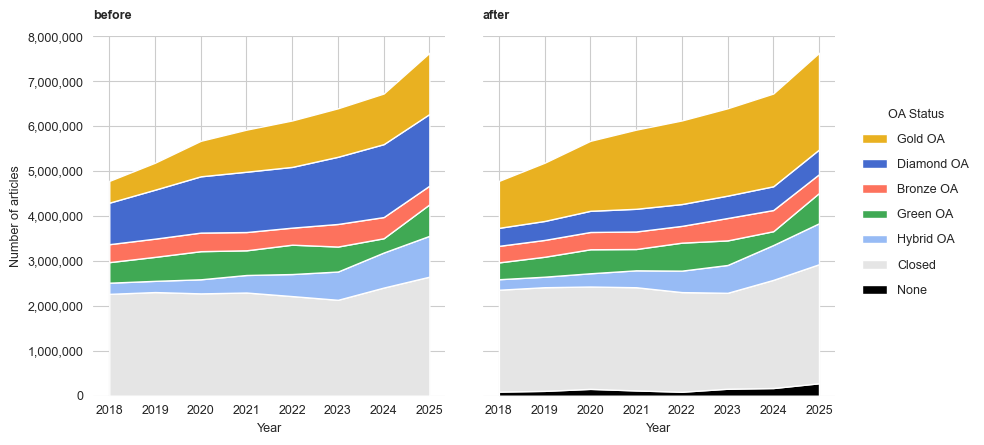

In [57]:
fig, (ax1, ax2) = plt.subplots(nrows=1, 
                               ncols=2, 
                               sharey=True,
                               figsize=(9,5))

ax1.set_frame_on(False)
ax2.set_frame_on(False)

ax1.stackplot([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025], 
              oa_df[oa_df.oa_status == 'closed']['n'].tolist(), 
              oa_df[oa_df.oa_status == 'hybrid']['n'].tolist(), 
              oa_df[oa_df.oa_status == 'green']['n'].tolist(), 
              oa_df[oa_df.oa_status == 'bronze']['n'].tolist(),
              oa_df[oa_df.oa_status == 'diamond']['n'].tolist(), 
              oa_df[oa_df.oa_status == 'gold']['n'].tolist(),
              colors=['#e5e5e5', '#97bbf5ff', '#40a954', '#fd725d', '#446ace', '#e9b121']
             )

ax2.stackplot([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025], 
              oa_new_df[oa_new_df.oa_status.isnull()]['n'].tolist(),
              oa_new_df[oa_new_df.oa_status == 'closed']['n'].tolist(), 
              oa_new_df[oa_new_df.oa_status == 'hybrid']['n'].tolist(), 
              oa_new_df[oa_new_df.oa_status == 'green']['n'].tolist(), 
              oa_new_df[oa_new_df.oa_status == 'bronze']['n'].tolist(),
              oa_new_df[oa_new_df.oa_status == 'diamond']['n'].tolist(), 
              oa_new_df[oa_new_df.oa_status == 'gold']['n'].tolist(),
              colors=['black', '#e5e5e5', '#97bbf5ff', '#40a954', '#fd725d', '#446ace', '#e9b121']
             )

ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax1.set_title('before', loc='left', pad=12.0, size=9, weight='bold')
ax2.set_title('after', loc='left', pad=12.0, size=9, weight='bold')

plt.xticks([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

ax1.set(xlabel='Year', ylabel='Number of articles')

ax2.set(xlabel='Year', ylabel='')

green_oa_patch = Patch(facecolor='#40a954', label='Green OA')
gold_oa_patch = Patch(facecolor='#e9b121', label='Gold OA')
bronze_oa_patch = Patch(facecolor='#fd725d', label='Bronze OA')
hybrid_oa_patch = Patch(facecolor='#97bbf5ff', label='Hybrid OA')
diamond_oa_patch = Patch(facecolor='#446ace', label='Diamond OA')
closed_oa_patch = Patch(facecolor='#e5e5e5', label='Closed')
is_null_oa_patch = Patch(facecolor='black', label='None')

lgd = fig.legend(handles=[gold_oa_patch, 
                          diamond_oa_patch,
                          bronze_oa_patch,
                          green_oa_patch, 
                          hybrid_oa_patch,
                          closed_oa_patch,
                          is_null_oa_patch], 
                 title='OA Status',
                 frameon=False,
                 bbox_to_anchor=(1.12, 0.75), labelspacing=1.05)

plt.tight_layout(pad=3.0)

plt.show()
fig.savefig('media/figure1_assumption_1.png', format='png', bbox_inches='tight', dpi=500)

In [58]:
calculate_changes(oa_df.groupby(['oa_status'], dropna=False)['n'].sum().reset_index(), 
                  oa_new_df.groupby(['oa_status'], dropna=False)['n'].sum().reset_index(), 
                  on='oa_status')

,oa_status,n_old,n_new,change,pct_change
0,bronze,3393868,3278440,-115428,-3.401075
1,closed,18554575,18554542,-33,-0.000178
2,diamond,10672256,3860946,-6811310,-63.822588
3,gold,7413941,13680286,6266345,84.521107
4,green,4394150,3978356,-415794,-9.462444
5,hybrid,4011103,3922591,-88512,-2.206675
6,NaN,0,1163823,1163823,inf


In [59]:
oa_df_share = oa_df.groupby(['oa_status'], dropna=False)['n'].sum().reset_index()

In [60]:
oa_df_share['total'] = oa_df_share['n'].sum()
oa_df_share['share'] = oa_df_share['n'] / oa_df_share['total']

oa_df_share

,oa_status,n,total,share
0,bronze,3393868,48439893,0.070063
1,closed,18554575,48439893,0.383043
2,diamond,10672256,48439893,0.22032
3,gold,7413941,48439893,0.153054
4,green,4394150,48439893,0.090713
5,hybrid,4011103,48439893,0.082806


In [61]:
oa_new_df_share = oa_new_df.groupby(['oa_status'], dropna=False)['n'].sum().reset_index()

In [62]:
oa_new_df_share['total'] = oa_new_df_share['n'].sum()
oa_new_df_share['share'] = oa_new_df_share['n'] / oa_new_df_share['total']

oa_new_df_share

,oa_status,n,total,share
0,bronze,3278440,48438984,0.067682
1,closed,18554542,48438984,0.38305
2,diamond,3860946,48438984,0.079707
3,gold,13680286,48438984,0.282423
4,green,3978356,48438984,0.082131
5,hybrid,3922591,48438984,0.08098
6,NaN,1163823,48438984,0.024027


## Assumption 2

In [35]:
oa_new_df2 = client.query(f"""
                          SELECT COUNT(DISTINCT(doi)) AS n,
                                 CASE
                                     WHEN best_oa_location_is_oa IS NULL THEN 'closed'
                                     WHEN best_oa_location_source_type='repository' THEN 'green'
                                     WHEN (best_oa_location_source_is_in_doaj=TRUE OR best_oa_location_source_is_oa=TRUE) AND apc_list_value=0 THEN 'diamond'
                                     WHEN (best_oa_location_source_is_in_doaj=TRUE OR best_oa_location_source_is_oa=TRUE) THEN 'gold'
                                     WHEN (best_oa_location_source_is_in_doaj=FALSE AND best_oa_location_source_is_oa=FALSE)
                                         AND best_oa_location_license IS NOT NULL THEN 'hybrid'
                                     WHEN (best_oa_location_source_is_in_doaj=FALSE AND best_oa_location_source_is_oa=FALSE) 
                                         AND best_oa_location_license IS NULL THEN 'bronze'
                                     ELSE NULL
                                     END
                                 AS oa_status,
                                 publication_year
                          FROM subugoe-collaborative.resources.walden_oa_articles_18_25
                          GROUP BY publication_year, oa_status
                          ORDER BY publication_year, oa_status DESC
                          """).to_dataframe()

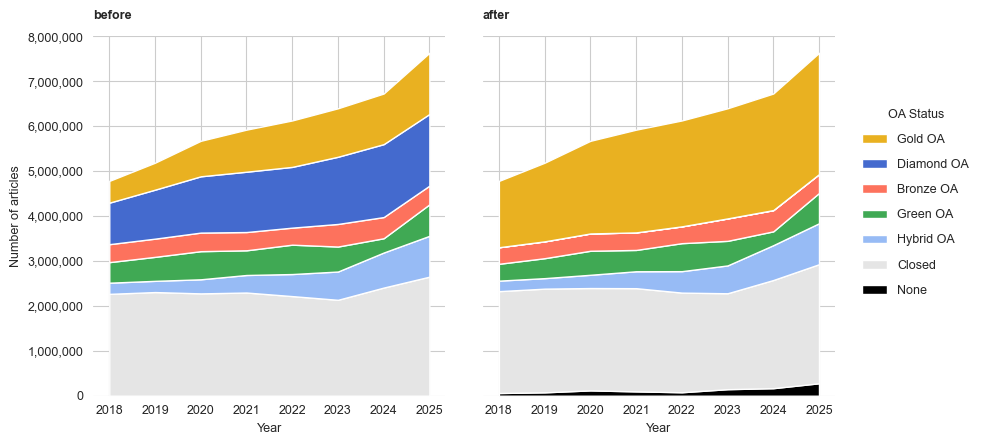

In [36]:
fig, (ax1, ax2) = plt.subplots(nrows=1, 
                               ncols=2, 
                               sharey=True,
                               figsize=(9,5))

ax1.set_frame_on(False)
ax2.set_frame_on(False)

ax1.stackplot([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025], 
              oa_df[oa_df.oa_status == 'closed']['n'].tolist(), 
              oa_df[oa_df.oa_status == 'hybrid']['n'].tolist(), 
              oa_df[oa_df.oa_status == 'green']['n'].tolist(), 
              oa_df[oa_df.oa_status == 'bronze']['n'].tolist(),
              oa_df[oa_df.oa_status == 'diamond']['n'].tolist(), 
              oa_df[oa_df.oa_status == 'gold']['n'].tolist(),
              colors=['#e5e5e5', '#97bbf5ff', '#40a954', '#fd725d', '#446ace', '#e9b121']
             )

ax2.stackplot([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025], 
              oa_new_df2[oa_new_df2.oa_status.isnull()]['n'].tolist(),
              oa_new_df2[oa_new_df2.oa_status == 'closed']['n'].tolist(), 
              oa_new_df2[oa_new_df2.oa_status == 'hybrid']['n'].tolist(), 
              oa_new_df2[oa_new_df2.oa_status == 'green']['n'].tolist(), 
              oa_new_df2[oa_new_df2.oa_status == 'bronze']['n'].tolist(),
              oa_new_df2[oa_new_df2.oa_status == 'diamond']['n'].tolist(), 
              oa_new_df2[oa_new_df2.oa_status == 'gold']['n'].tolist(),
              colors=['black', '#e5e5e5', '#97bbf5ff', '#40a954', '#fd725d', '#446ace', '#e9b121']
             )

ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax1.set_title('before', loc='left', pad=12.0, size=9, weight='bold')
ax2.set_title('after', loc='left', pad=12.0, size=9, weight='bold')

plt.xticks([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

ax1.set(xlabel='Year', ylabel='Number of articles')

ax2.set(xlabel='Year', ylabel='')

green_oa_patch = Patch(facecolor='#40a954', label='Green OA')
gold_oa_patch = Patch(facecolor='#e9b121', label='Gold OA')
bronze_oa_patch = Patch(facecolor='#fd725d', label='Bronze OA')
hybrid_oa_patch = Patch(facecolor='#97bbf5ff', label='Hybrid OA')
diamond_oa_patch = Patch(facecolor='#446ace', label='Diamond OA')
closed_oa_patch = Patch(facecolor='#e5e5e5', label='Closed')
is_null_oa_patch = Patch(facecolor='black', label='None')

lgd = fig.legend(handles=[gold_oa_patch, 
                          diamond_oa_patch,
                          bronze_oa_patch,
                          green_oa_patch, 
                          hybrid_oa_patch,
                          closed_oa_patch,
                          is_null_oa_patch], 
                 title='OA Status',
                 frameon=False,
                 bbox_to_anchor=(1.12, 0.75), labelspacing=1.05)

plt.tight_layout(pad=3.0)

plt.show()
fig.savefig('media/figure1_assumption_2.png', format='png', bbox_inches='tight', dpi=500)

In [37]:
calculate_changes(oa_df.groupby(['oa_status'], dropna=False)['n'].sum().reset_index(), 
                  oa_new_df2.groupby(['oa_status'], dropna=False)['n'].sum().reset_index(), 
                  on='oa_status')

,oa_status,n_old,n_new,change,pct_change
0,bronze,3393868,3278440,-115428,-3.401075
1,closed,18554575,18554542,-33,-0.000178
2,diamond,10672256,7121,-10665135,-99.933276
3,gold,7413941,17676305,10262364,138.419823
4,green,4394150,3978356,-415794,-9.462444
5,hybrid,4011103,3922591,-88512,-2.206675
6,NaN,0,1020895,1020895,inf


In [38]:
oa_new_df_share2 = oa_new_df2.groupby(['oa_status'], dropna=False)['n'].sum().reset_index()

In [39]:
oa_new_df_share2['total'] = oa_new_df_share2['n'].sum()
oa_new_df_share2['share'] = oa_new_df_share2['n'] / oa_new_df_share2['total']

oa_new_df_share2

,oa_status,n,total,share
0,bronze,3278440,48438250,0.067683
1,closed,18554542,48438250,0.383056
2,diamond,7121,48438250,0.000147
3,gold,17676305,48438250,0.364925
4,green,3978356,48438250,0.082133
5,hybrid,3922591,48438250,0.080981
6,NaN,1020895,48438250,0.021076


## Check new OA status = NULL

In [13]:
oa_null_df = client.query(f"""
                          SELECT DISTINCT all_pubs.doi,
                                   best_oa_location_is_oa, 
                                   best_oa_location_source_is_oa, 
                                   best_oa_location_license, 
                                   best_oa_location_source_type, 
                                   best_oa_location_source_host_organization_name, 
                                   best_oa_location_pdf_url,
                                   best_oa_location_source_is_in_doaj,
                                   apc_list_value_usd, 
                                   apc_list_value, 
                                   original_is_oa,
                                   original_oa_status, 
                                   publication_year
                            FROM (
                                  SELECT doi,
                                        CASE
                                              WHEN best_oa_location_is_oa IS NULL THEN 'closed'
                                              WHEN best_oa_location_source_type='repository' THEN 'green'
                                              WHEN (best_oa_location_source_is_in_doaj=TRUE OR best_oa_location_source_is_oa=TRUE) AND apc_list_value=0 THEN 'diamond'
                                              WHEN (best_oa_location_source_is_in_doaj=TRUE OR best_oa_location_source_is_oa=TRUE) THEN 'gold'
                                              WHEN (best_oa_location_source_is_in_doaj=FALSE AND best_oa_location_source_is_oa=FALSE)
                                              AND best_oa_location_license IS NOT NULL THEN 'hybrid'
                                              WHEN (best_oa_location_source_is_in_doaj=FALSE AND best_oa_location_source_is_oa=FALSE) 
                                              AND best_oa_location_license IS NULL THEN 'bronze'
                                              ELSE NULL
                                              END
                                        AS new_oa_status
                                  FROM subugoe-collaborative.resources.walden_oa_articles_18_25
                            ) AS with_null
                            JOIN subugoe-collaborative.resources.walden_oa_articles_18_25 AS all_pubs
                                  ON with_null.doi = all_pubs.doi
                            WHERE new_oa_status IS NULL
                            LIMIT 50
                          """).to_dataframe()

In [14]:
oa_null_df.head()

,doi,best_oa_location_is_oa,best_oa_location_source_is_oa,best_oa_location_license,best_oa_location_source_type,best_oa_location_source_host_organization_name,best_oa_location_pdf_url,best_oa_location_source_is_in_doaj,apc_list_value_usd,apc_list_value,original_is_oa,original_oa_status,publication_year
0,10.18699/bgrs2024-3.2-18,True,<NA>,None,None,None,http://dx.doi.org/10.18699/bgrs2024-3.2-18,<NA>,NaN,NaN,True,gold,2024
1,10.51189/ensipex2024/28541,True,<NA>,None,None,None,http://dx.doi.org/10.51189/ensipex2024/28541,<NA>,NaN,NaN,True,gold,2024
2,10.18690/um.fov.2.2025.41,True,<NA>,cc-by,None,None,https://press.um.si/index.php/ump/catalog/down...,<NA>,NaN,NaN,True,gold,2025
3,10.18653/v1/d18-2008,True,<NA>,cc-by,None,None,https://www.aclweb.org/anthology/D18-2008.pdf,<NA>,NaN,NaN,True,gold,2018
4,10.82519/thpq.v91i3.46558,True,<NA>,None,None,None,None,<NA>,NaN,NaN,True,gold,2025


## Check APC

In [40]:
has_apc = client.query(f"""
                        SELECT COUNT(DISTINCT(doi)) AS n,
                               CASE
                                   WHEN apc_list_value IS NOT NULL THEN TRUE
                                   ELSE FALSE
                               END AS has_apc_value,
                                publication_year
                        FROM subugoe-collaborative.resources.walden_oa_articles_18_25
                        WHERE original_is_oa=TRUE
                        GROUP BY publication_year, has_apc_value
                        ORDER BY publication_year DESC
                        """).to_dataframe()

In [41]:
has_apc_usd = client.query(f"""
                        SELECT COUNT(DISTINCT(doi)) AS n,
                               CASE 
                                   WHEN apc_list_value_usd IS NOT NULL THEN TRUE
                                   ELSE FALSE
                                END AS has_apc_usd_value,
                                publication_year
                        FROM subugoe-collaborative.resources.walden_oa_articles_18_25
                        WHERE original_is_oa=TRUE
                        GROUP BY publication_year, has_apc_usd_value
                        ORDER BY publication_year DESC
                        """).to_dataframe()

In [42]:
has_apc_old = client.query(f"""
                            SELECT COUNT(DISTINCT(r.doi)) AS n,
                                   CASE
                                       WHEN apc_list.value IS NOT NULL THEN TRUE
                                       ELSE FALSE
                                   END AS has_apc_value,
                                   r.publication_year
                            FROM subugoe-collaborative.resources.walden_oa_articles_18_25 AS r
                            JOIN subugoe-collaborative.openalex.works AS oal
                              ON r.doi = oal.doi
                            WHERE original_is_oa=TRUE
                            GROUP BY publication_year, has_apc_value
                            ORDER BY publication_year DESC
                            """).to_dataframe()

In [43]:
has_apc_total = has_apc.groupby(['publication_year'])['n'].sum().reset_index()
has_apc_total.rename(columns={'n':'n_total'}, inplace=True)
has_apc_plot = pd.merge(has_apc, has_apc_total, on='publication_year')

has_apc_plot['share'] = has_apc_plot['n'] / has_apc_plot['n_total']

In [44]:
has_apc_usd_total = has_apc_usd.groupby(['publication_year'])['n'].sum().reset_index()
has_apc_usd_total.rename(columns={'n':'n_total'}, inplace=True)
has_apc_usd_plot = pd.merge(has_apc_usd, has_apc_usd_total, on='publication_year')

has_apc_usd_plot['share'] = has_apc_usd_plot['n'] / has_apc_usd_plot['n_total']

In [45]:
has_apc_old_total = has_apc_old.groupby(['publication_year'])['n'].sum().reset_index()
has_apc_old_total.rename(columns={'n':'n_total'}, inplace=True)
has_apc_old_plot = pd.merge(has_apc_old, has_apc_old_total, on='publication_year')

has_apc_old_plot['share'] = has_apc_old_plot['n'] / has_apc_old_plot['n_total']

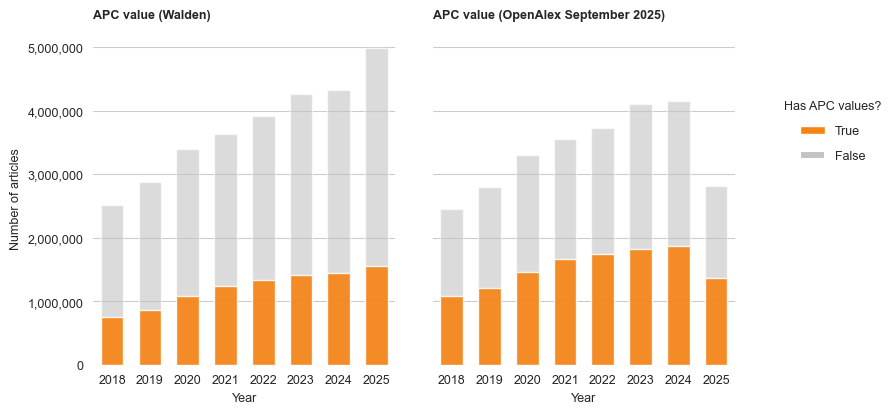

In [46]:
fig, (ax1, ax2) = plt.subplots(nrows=1, 
                               ncols=2, 
                               sharey=True,
                               figsize=(8,4.7))

ax1.set_frame_on(False)
ax2.set_frame_on(False)

sns.barplot(data=has_apc_plot,
             x='publication_year',
             y='n_total',
             color='#c3c3c3',
             width=0.6,
             saturation=1,
             alpha=0.6,
             errorbar=None,
             ax=ax1)

sns.barplot(data=has_apc_plot[has_apc_plot.has_apc_value==True],
             x='publication_year',
             y='n',
             color='#f68212',
             width=0.6,
             saturation=1,
             alpha=0.9,
             errorbar=None,
             ax=ax1)

sns.barplot(data=has_apc_old_plot,
             x='publication_year',
             y='n_total',
             color='#c3c3c3',
             width=0.6,
             saturation=1,
             alpha=0.6,
             errorbar=None,
             ax=ax2)

sns.barplot(data=has_apc_old_plot[has_apc_old_plot.has_apc_value==True],
             x='publication_year',
             y='n',
             color='#f68212',
             width=0.6,
             saturation=1,
             alpha=0.9,
             errorbar=None,
             ax=ax2)


ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax1.set(xlabel='Year', ylabel='Number of articles')

ax2.set(xlabel='Year', ylabel='')

ax1.set_title('APC value (Walden)', loc='left', pad=10.0, size=9, weight='bold')
ax2.set_title('APC value (OpenAlex September 2025)', loc='left', pad=10.0, size=9, weight='bold')

has_apc_patch = Patch(facecolor='#f68212', linewidth=1, label='True')
no_apc_patch = Patch(facecolor='#c3c3c3', linewidth=1.5, label='False')

lgd = fig.legend(handles=[has_apc_patch, 
                          no_apc_patch], 
                 title='Has APC values?',
                 frameon=False,
                 bbox_to_anchor=(1.15, 0.75), 
                 labelspacing=1.05)

plt.tight_layout(pad=3.0)

plt.show()
fig.savefig('media/figure3.png', format='png', bbox_inches='tight', dpi=500)

In [47]:
has_apc_plot[has_apc_plot.publication_year == 2024]

,n,has_apc_value,publication_year,n_total,share
2,2868186,False,2024,4318508,0.664161
3,1450322,True,2024,4318508,0.335839


In [48]:
has_apc_old_plot[has_apc_old_plot.publication_year == 2024]

,n,has_apc_value,publication_year,n_total,share
2,2283477,False,2024,4150307,0.550195
3,1866830,True,2024,4150307,0.449805


In [49]:
oa_diamond_df = client.query(f"""
                              SELECT COUNT(DISTINCT(doi)) AS n,
                                     apc_list_value_usd, 
                                     apc_list_value, 
                                     publication_year
                              FROM subugoe-collaborative.resources.walden_oa_articles_18_25
                              WHERE original_oa_status='diamond'
                              GROUP BY publication_year, apc_list_value_usd, apc_list_value
                              ORDER BY publication_year, apc_list_value_usd, apc_list_value DESC
                              """).to_dataframe()

In [50]:
oa_diamond_df[oa_diamond_df.apc_list_value_usd.isnull()].groupby(['publication_year'])['n'].sum()

publication_year
2018     922910
2019    1089542
2020    1252127
2021    1341641
2022    1351273
2023    1494260
2024    1620860
2025    1592633
Name: n, dtype: Int64